In [36]:
# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

# Load an example dataset
tips = sns.load_dataset("tips")
tips


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


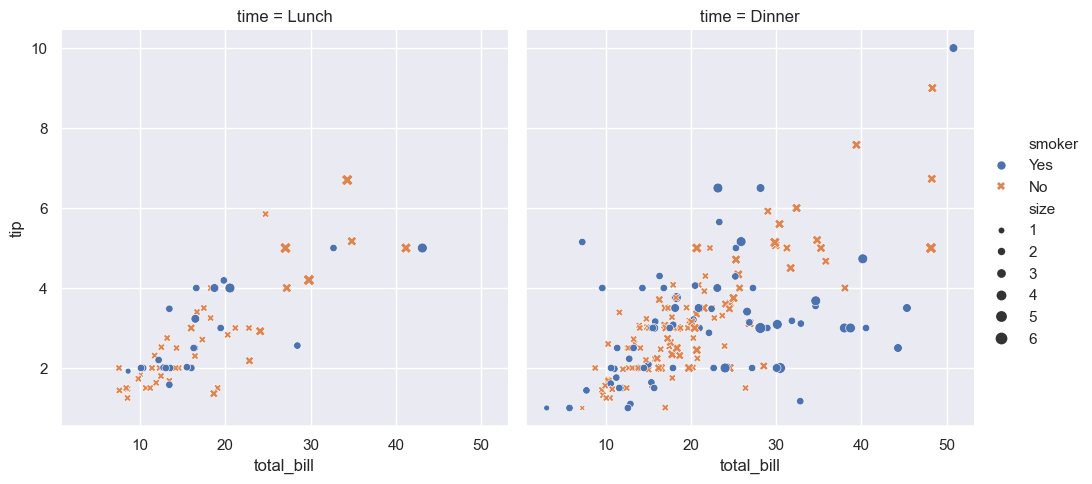

In [ ]:
# Create a visualization

sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

# hue signifie teinte, nuance

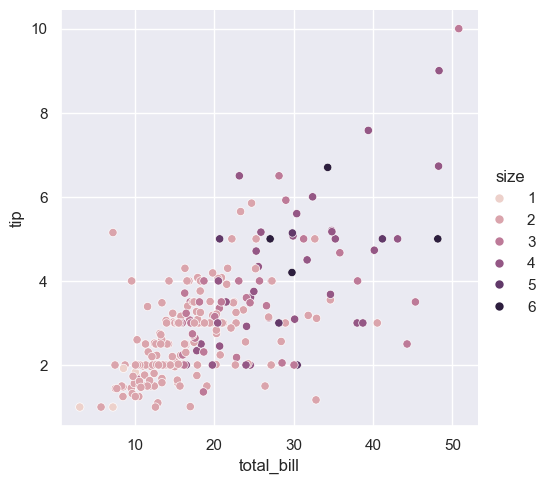

In [ ]:
# relplot ou relational plot
sns.relplot(
    data=tips, x="total_bill", y="tip", hue="size",
)

# Par défaut, relplot utilise un scatter plot

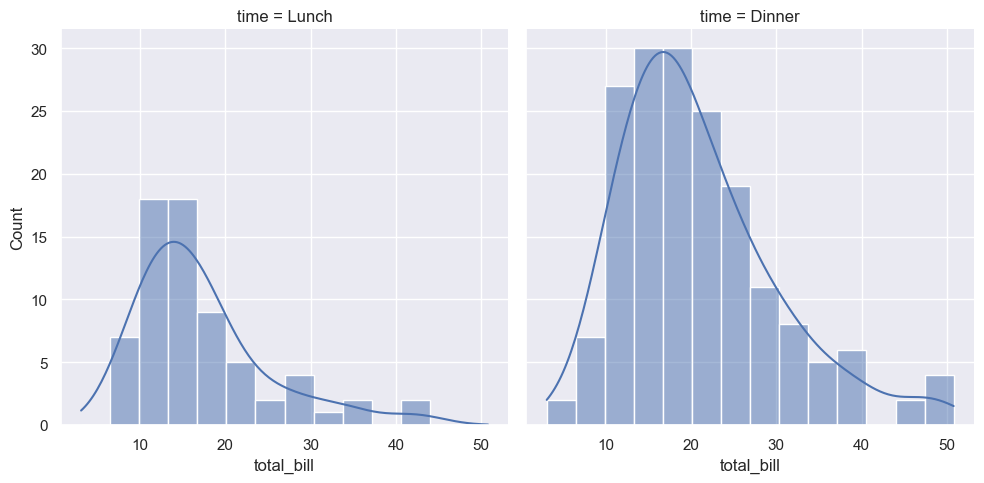

In [ ]:
# Distribution de données
# Histogramme
sns.displot(data=tips, x="total_bill", col="time", kde=True)

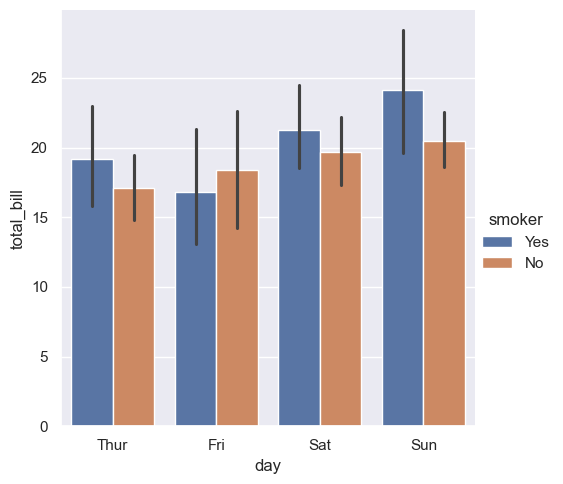

In [ ]:
# Graphiques par catégorie
# Catplot
sns.catplot(data=tips, kind="bar", x="day", y="total_bill", hue="smoker")


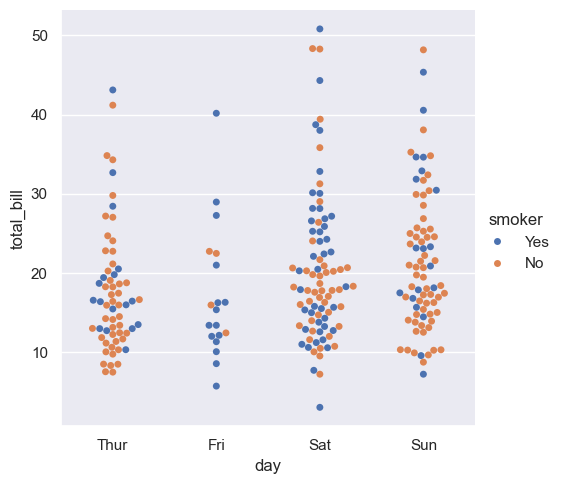

In [ ]:
sns.catplot(data=tips, kind="swarm", x="day", y="total_bill", hue="smoker")
# swarm = nuée

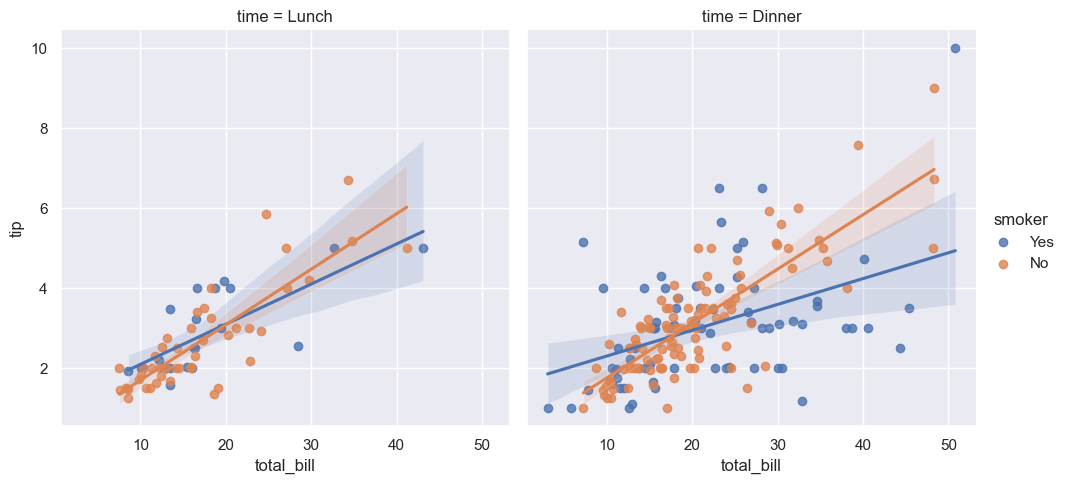

In [ ]:
# Application data science
# lmplot = linear model plot
sns.lmplot(data=tips, x="total_bill", y="tip", col="time", hue="smoker")


Titanic

<Axes: ylabel='survived'>

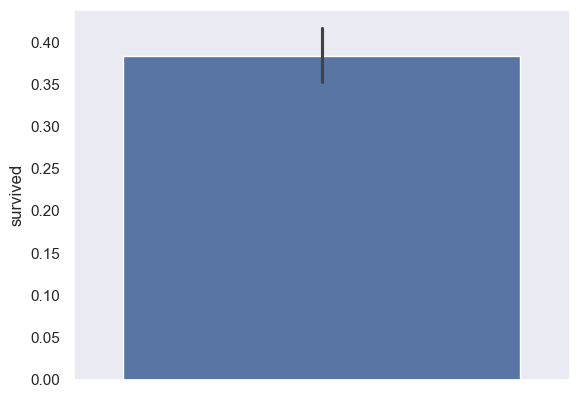

In [ ]:
# Exercice 
# Représenter avec un barplot le nombre de survivants du Titanic
# 1. D'abord avec une seule barre
# 2. Ajouter ensuite une autre barre pour faire une distinction par genre
# 3. Utiliser ensuite de la couleur pour ajouter une nouvelle distinction par classe

titanic = sns.load_dataset("titanic")
sns.barplot(data=titanic, y="survived")

<Axes: xlabel='sex', ylabel='survived'>

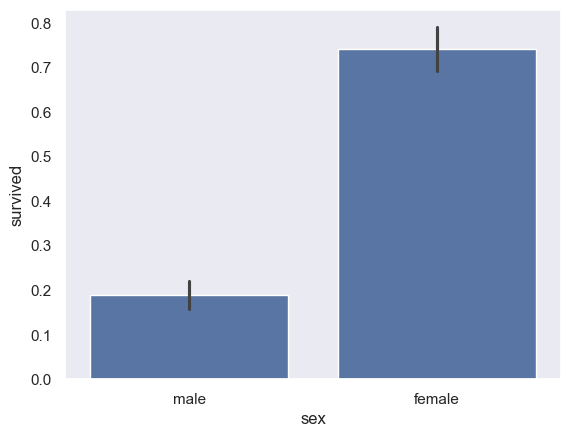

In [ ]:
sns.barplot(data=titanic, x="sex", y="survived" )

<Axes: ylabel='survived'>

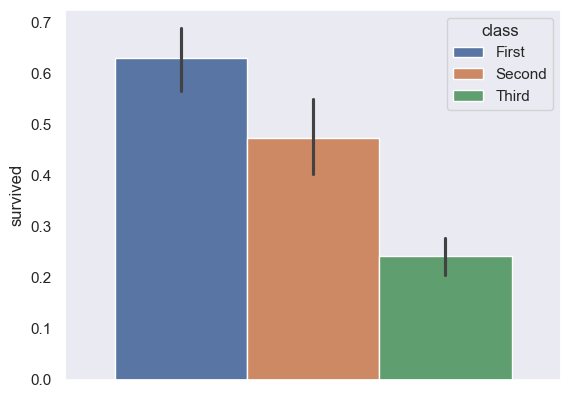

In [75]:
sns.barplot(data=titanic, y="survived", hue="class")

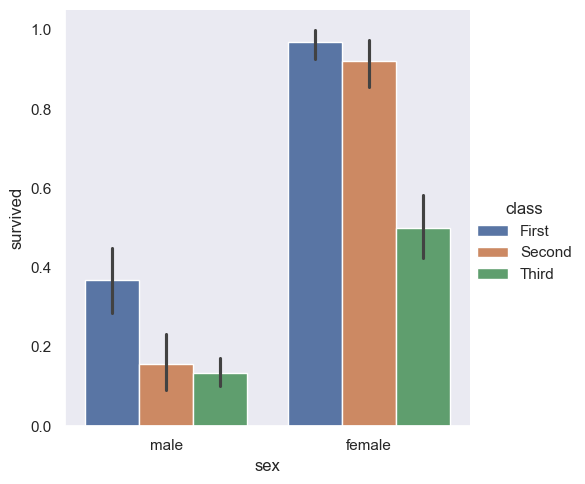

In [72]:
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="bar")

<Axes: xlabel='class', ylabel='survived'>

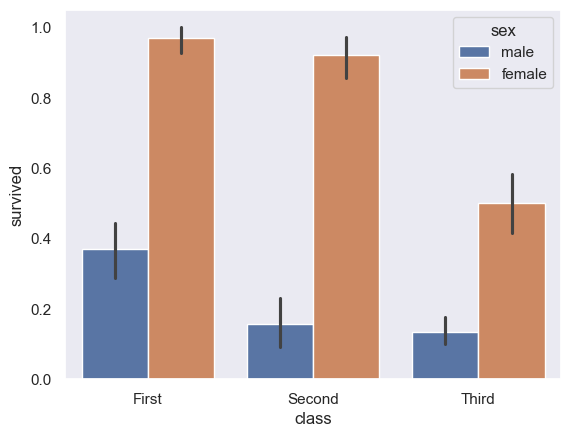

In [76]:
sns.barplot(data=titanic, x="class", y="survived", hue="sex")

In [10]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


<Axes: xlabel='class', ylabel='age'>

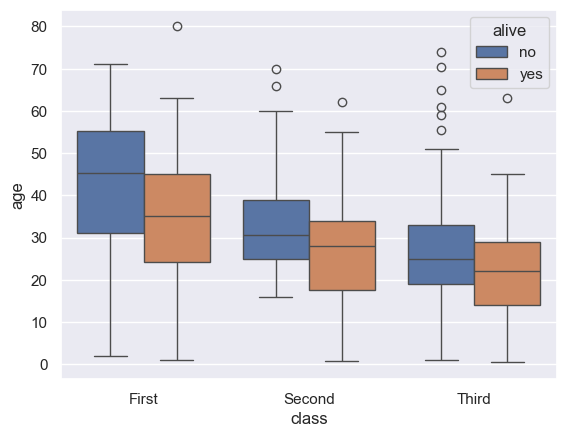

In [ ]:
# box plot
# Repreentation des caracteristiques statistiques
sns.boxplot(data=titanic, x="class", y="age", hue="alive")

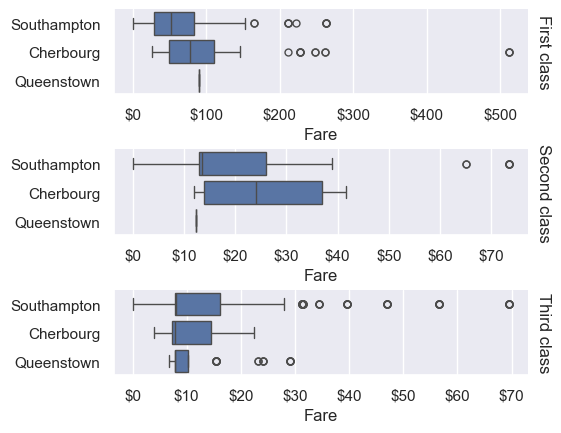

In [ ]:
# Un bos plot plus élaboré
g = sns.catplot(
    data=titanic,
    x="fare", y="embark_town", row="class",
    kind="box", orient="h",
    sharex=False, margin_titles=True,
    height=1.5, aspect=4,
)
g.set(xlabel="Fare", ylabel="")
g.set_titles(row_template="{row_name} class")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter('${x:.0f}')

In [62]:
# Exercice
# Afficher le nombre de naissances entre 2020 et 2024 à l'aide d'une heatmap de Seaborn



# Etapes proposées
# 1. Récupérer les données sur le site de l'insee : https://www.insee.fr/fr/statistiques/serie/000436391#Telechargement
# 2. Charger les données dans un dataframe pandas
# 3. Avoir trois colonnes : Année, mois, nombre
# 4. Transformer le dataframe pour avoir en index les mois et en colonnes les années
# 5. Afficher la heatmap avec seaborn


In [ ]:
import pandas


df = pandas.read_csv("../data/valeurs_mensuelles.csv", sep=";", header=None, names=["date", "valeur", "X"])
df = df[["date", "valeur"]]


df["year"] = df["date"].str.split("-").str[0]
df["month"] = df["date"].str.split("-").str[1]
df["valeur"] = df["valeur"]/1000
df = df.loc[df["year"].astype(int) < 2025]
df.head()

,date,valeur,year,month
2,2024-12,51.4,2024,12
3,2024-11,50.7,2024,11
4,2024-10,54.4,2024,10
5,2024-09,52.5,2024,09
6,2024-08,54.1,2024,08


In [63]:
naissances = df.pivot_table(index="month", columns="year", values="valeur")
naissances = naissances.astype(int)
naissances


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month,,,,,,,,,,,,,,,,,,,,,
01,63,64,63,63,64,63,64,66,66,66,...,64,62,60,59,59,59,51,57,53,53
02,60,57,57,58,59,58,59,59,61,58,...,57,57,54,52,51,53,49,52,49,50
03,64,63,62,62,60,63,65,64,64,64,...,61,59,58,56,56,57,57,56,52,51
04,62,62,61,62,61,62,61,60,65,63,...,59,57,57,55,55,54,56,54,50,50
05,67,67,64,65,61,65,68,66,68,66,...,64,62,62,61,60,58,57,58,53,53
06,63,63,62,62,63,63,66,64,65,65,...,63,62,59,60,59,58,57,58,53,50
07,67,68,67,67,68,66,69,68,70,70,...,66,67,65,64,64,62,62,61,56,54
08,66,66,65,64,65,67,68,68,67,68,...,65,65,64,63,62,60,62,60,55,54
09,64,63,64,63,65,66,69,66,67,67,...,65,63,61,61,61,59,61,56,52,52


<Axes: xlabel='year', ylabel='month'>

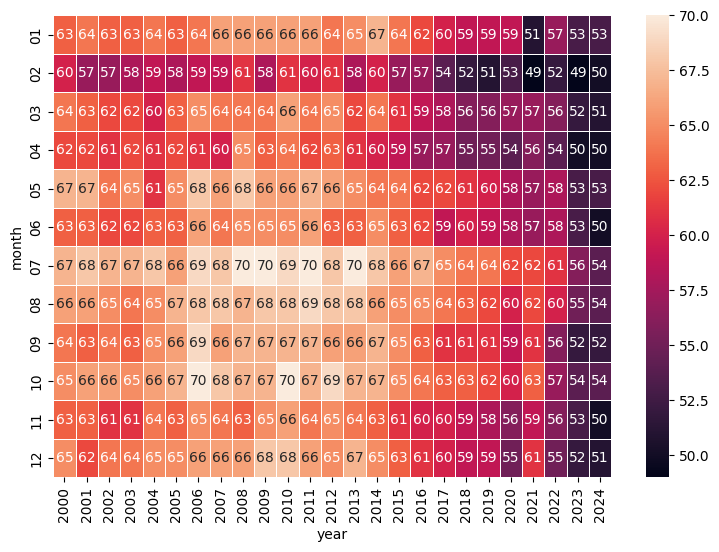

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(naissances, annot=True, fmt="d", linewidths=.5, ax=ax)

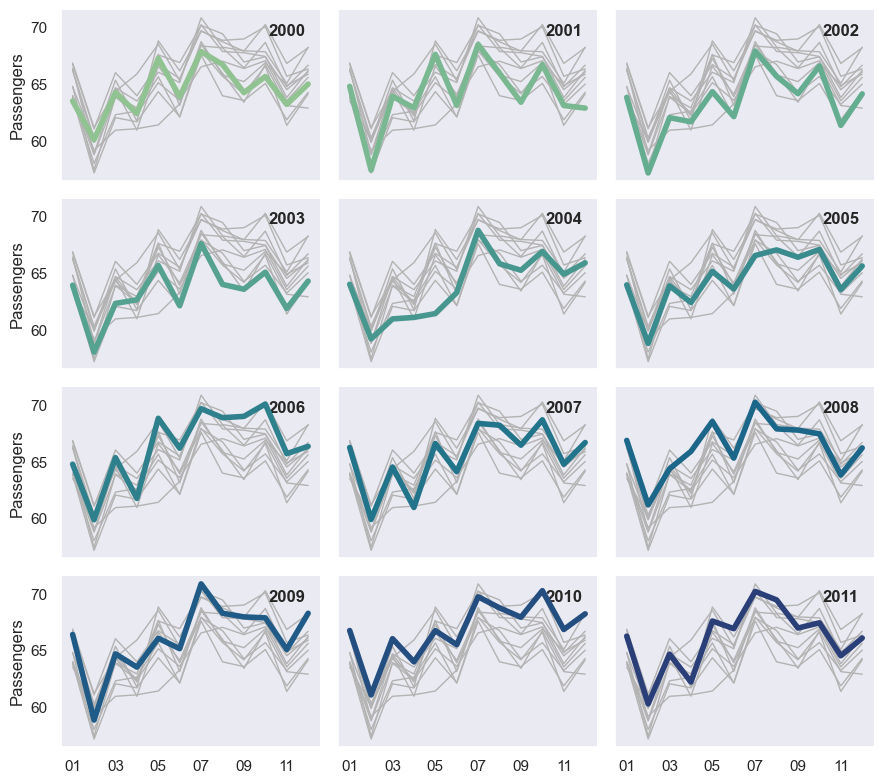

In [58]:
# Exercice 2 
# Représenter la même donées mais avec un lineplot

selected_df = df.loc[df["year"].astype(int) < 2012]

selected_df = selected_df[["year", "month", "valeur"]]
selected_df = selected_df.sort_values(by=["year", "month"])

g = sns.relplot(data=selected_df, x="month", y="valeur",col="year", hue="year",
            palette="crest",
            kind="line",
            linewidth=4, 
            zorder=5,
            col_wrap=3, height=2, aspect=1.5, legend=False,
)


# Iterate over each subplot to customize further
for year, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    ax.text(.8, .85, year, transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=selected_df, x="month", y="valeur", units="year",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("")
g.set_axis_labels("", "Passengers")
g.tight_layout()